### Exploração inicial `SLCE3`. Quais relações podemos identificar?

#### Apresentação e tratamento
Vamos cobrir o periodo de `2018-01-02` a `2024-12-30`

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression


# Carrega o dataset
df = pd.read_csv('SLCE3.csv')

# Exibe as primeiras 5 linhas do DataFrame
print("Primeiras 5 linhas do DataFrame:")
print(df.head())

# Exibe informações gerais sobre o DataFrame
print("\nInformações gerais do DataFrame:")
print(df.info())


# Verifica se há valores negativos nas colunas 'Close' e 'Open'
print("\nVerificando valores negativos nas colunas 'Close' e 'Open':")
negative_close = df[df['Close'] < 0]
negative_open = df[df['Open'] < 0]
negative_high = df[df['High'] < 0]
negative_low = df[df['Low'] < 0]
negative_volum = df[df['Volume'] < 0]

if negative_close.empty:
    print("\nNão há valores negativos na coluna 'Close'.")

if negative_open.empty:
    print("Não há valores negativos na coluna 'Open'.")

if negative_high.empty:
    print("Não há valores negativos na coluna 'High'.")

if negative_low.empty:
    print("Não há valores negativos na coluna 'Low'.")

if negative_volum.empty:
    print("Não há valores negativos na coluna 'Volume'.")



Primeiras 5 linhas do DataFrame:
         Date     Close      High       Low      Open   Volume
0  2018-01-02  3.077934  3.103537  2.972182  2.972182  1227908
1  2018-01-03  3.104650  3.215968  3.067915  3.077933  2494536
2  2018-01-04  3.092405  3.198157  3.055670  3.104650  2957724
3  2018-01-05  3.150290  3.166988  3.069028  3.138046  2140248
4  2018-01-08  3.133592  3.183685  3.112442  3.150290  1613172

Informações gerais do DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1738 entries, 0 to 1737
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    1738 non-null   object 
 1   Close   1738 non-null   float64
 2   High    1738 non-null   float64
 3   Low     1738 non-null   float64
 4   Open    1738 non-null   float64
 5   Volume  1738 non-null   int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 81.6+ KB
None

Verificando valores negativos nas colunas 'Close' e 'Open':

Não há valores negativo

### Avaliando dataset

Primeiras 5 linhas do DataFrame com a nova coluna 'Close_Open_Diff':
         Date     Close      High       Low      Open   Volume  \
0  2018-01-02  3.077934  3.103537  2.972182  2.972182  1227908   
1  2018-01-03  3.104650  3.215968  3.067915  3.077933  2494536   
2  2018-01-04  3.092405  3.198157  3.055670  3.104650  2957724   
3  2018-01-05  3.150290  3.166988  3.069028  3.138046  2140248   
4  2018-01-08  3.133592  3.183685  3.112442  3.150290  1613172   

   Close_Open_Diff  
0         0.105752  
1         0.026716  
2        -0.012245  
3         0.012245  
4        -0.016698  

Estatísticas descritivas do DataFrame (com 'Close_Open_Diff'):
             Close         High          Low         Open        Volume  \
count  1738.000000  1738.000000  1738.000000  1738.000000  1.738000e+03   
mean     12.853513    13.075743    12.651012    12.864267  3.029539e+06   
std       5.343477     5.411924     5.279755     5.346681  1.646280e+06   
min       3.077934     3.103537     2.972182

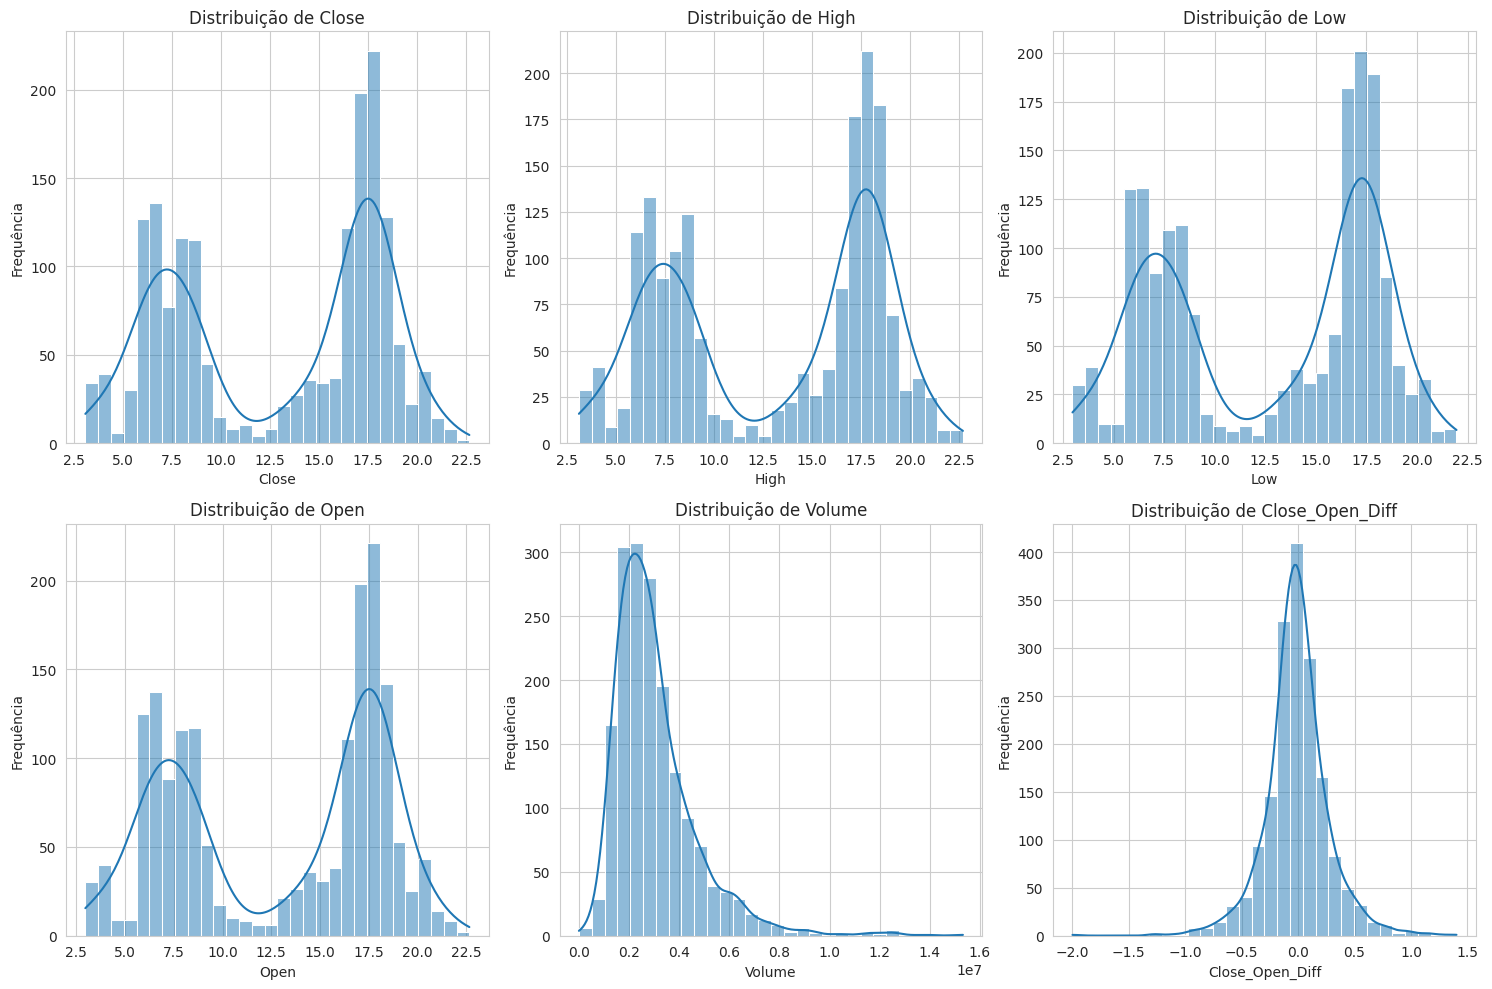

In [ ]:
df['Close_Open_Diff'] = df['Close'] - df['Open']

print("Primeiras 5 linhas do DataFrame com a nova coluna 'Close_Open_Diff':")
print(df.head())

sns.set_style("whitegrid")

columns_to_plot = ['Close', 'High', 'Low', 'Open', 'Volume', 'Close_Open_Diff']
plt.figure(figsize=(15, 10))
for i, col in enumerate(columns_to_plot):
    plt.subplot(2, 3, i + 1) # 2 linhas, 3 colunas de gráficos
    sns.histplot(df[col], kde=True, bins=30) # type: ignore
    plt.title(f'Distribuição de {col}')
    plt.xlabel(col)
    plt.ylabel('Frequência')

plt.tight_layout()
plt.savefig('distribuicao_dados_exploratorio.png')

# Exibir estatísticas descritivas atualizadas com a nova coluna
print("\nEstatísticas descritivas do DataFrame (com 'Close_Open_Diff'):")
print(df.describe())


#Linha KDE (Estimativa de Probabilidade - Onde os dados TENDEM a estar)

### Valor de fechamento em função do tempo.

/tmp/ipykernel_59870/1985960814.py:9: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  for name, group in df.groupby(pd.Grouper(freq='M')):



Gráfico 'Preço de Fechamento ao Longo do Tempo' salvo como 'close_price_over_time_monthly_sample.png'


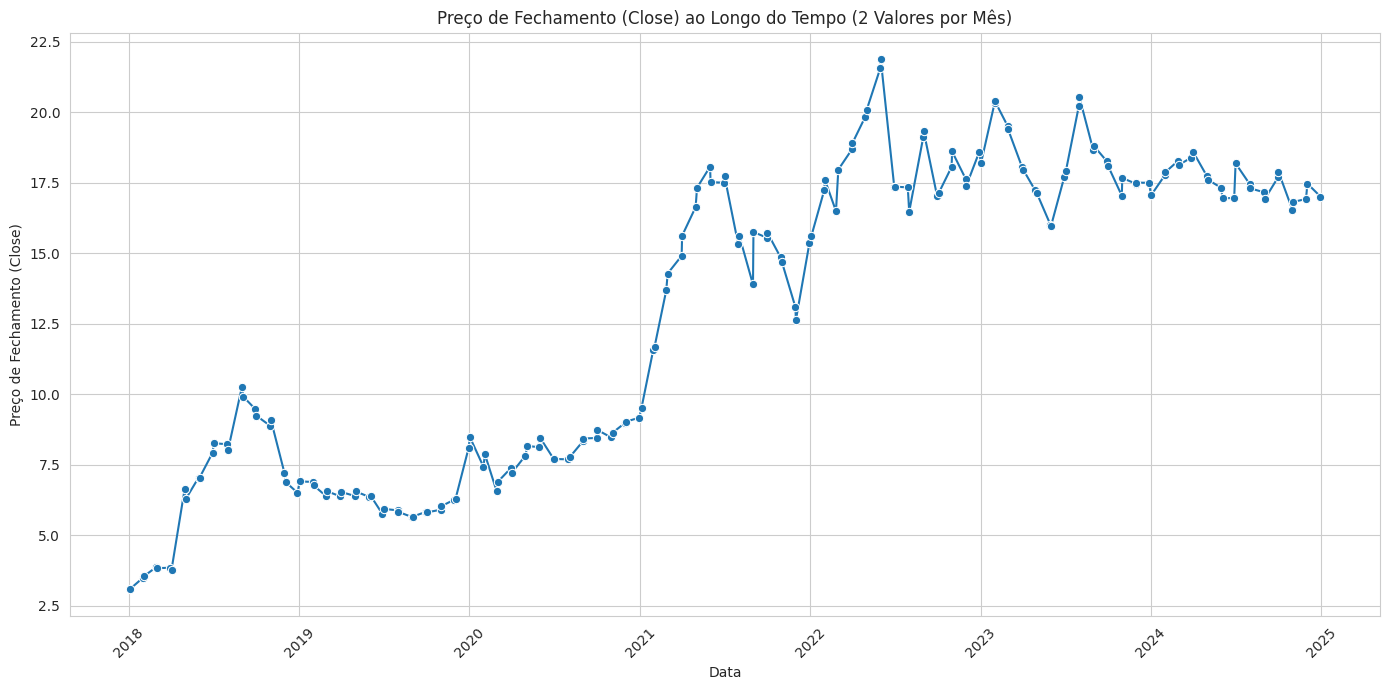

In [18]:
df['Date'] = pd.to_datetime(df['Date'])

# Definir 'Date' como índice para facilitar a amostragem temporal
df.set_index('Date', inplace=True)

# Amostrar 2 valores por mês: vamos pegar o primeiro e o último preço de fechamento do mês
# Uma forma mais robusta de pegar 2 valores por mês, garantindo que sejam distintos se o mês tiver pelo menos 2 dias.
resampled_data = []
for name, group in df.groupby(pd.Grouper(freq='M')):
    if len(group) >= 2:
        resampled_data.append(group.iloc[[0, -1]]['Close'])
    elif len(group) == 1: # Caso o mês tenha apenas um dia de negociação
        resampled_data.append(group.iloc[[0]]['Close'])

sampled_close_prices = pd.concat(resampled_data)

# Criar o gráfico
plt.figure(figsize=(14, 7))
sns.lineplot(x=sampled_close_prices.index, y=sampled_close_prices.values, marker='o', linestyle='-')
plt.title('Preço de Fechamento (Close) ao Longo do Tempo (2 Valores por Mês)')
plt.xlabel('Data')
plt.ylabel('Preço de Fechamento (Close)')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('close_price_over_time_monthly_sample.png')
print("\nGráfico 'Preço de Fechamento ao Longo do Tempo' salvo como 'close_price_over_time_monthly_sample.png'")

### Treinamento para modelo de regressão linear.


Gráfico de regressão para 'Open' vs 'Close' salvo como 'regressao_open_close.png'

Métricas do Modelo de Regressão Linear ('Open' vs 'Close'):
Coeficiente (Slope): 0.9988
Intercepto (Intercept): 0.0099
R-quadrado (R²): 0.9975


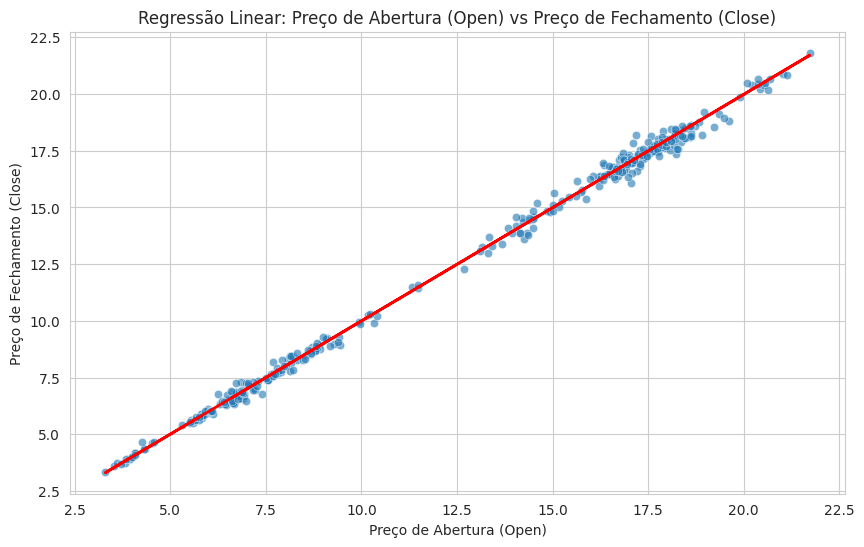

In [ ]:
# Definir o atributo alvo (variável dependente)
y = df['Close']

# Definir os atributos (variáveis independentes) para análise
features = ['Open', 'High', 'Low', 'Volume', 'Close_Open_Diff']

# Começaremos com 'Open'
X_open = df[['Open']]

# Dividir os dados em conjuntos de treino e teste
# Usaremos 80% dos dados para treino e 20% para teste
# random_state garante que a divisão seja a mesma sempre que o código for executado
X_train_open, X_test_open, y_train, y_test = train_test_split(X_open, y, test_size=0.2, random_state=42)

model_open = LinearRegression()

# Treinar o modelo com os dados de treino
model_open.fit(X_train_open, y_train)

# Fazer previsões nos dados de teste
y_pred_open = model_open.predict(X_test_open)

# --- Visualização do Modelo 'Open' vs 'Close' ---

plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_test_open['Open'], y=y_test, alpha=0.6) # Dados reais (teste)
plt.plot(X_test_open['Open'], y_pred_open, color='red', linewidth=2) # Linha de regressão
plt.title('Regressão Linear: Preço de Abertura (Open) vs Preço de Fechamento (Close)')
plt.xlabel('Preço de Abertura (Open)')
plt.ylabel('Preço de Fechamento (Close)')
plt.grid(True)
plt.savefig('regressao_open_close.png')
print("\nGráfico de regressão para 'Open' vs 'Close' salvo como 'regressao_open_close.png'")

# --- Métricas do Modelo 'Open' vs 'Close' ---
print("\nMétricas do Modelo de Regressão Linear ('Open' vs 'Close'):")
print(f"Coeficiente (Slope): {model_open.coef_[0]:.4f}")
print(f"Intercepto (Intercept): {model_open.intercept_:.4f}") # não faz tanto sentido para o caso pois uma ação com a abertura.
print(f"R-quadrado (R²): {model_open.score(X_test_open, y_test):.4f}")

*Há uma relação linear muito forte e positiva entre o preço de Abertura e o preço de Fechamento. O preço de abertura é um excelente preditor do preço de fechamento para este dataset, o que é logicamente esperado, já que o preço de fechamento de um dia e o de abertura do próximo geralmente estão muito correlacionados (com pequenas flutuações).*

*Nosso R2 de 0.9975 é excepcional, indicando que aproximadamente 99.75% da variação no preço de Fechamento pode ser explicada pelas mudanças no preço de Abertura. Isso sugere uma relação linear extremamente forte e que o Open é um preditor quase perfeito para o Close neste conjunto de dados.*

*Neste caso, um coeficiente de 0.9988 para Open significa que, para cada aumento de 1 unidade monetária no preço de Abertura, o preço de Fechamento tende a aumentar em aproximadamente 0.9988 unidade monetária. Um valor tão próximo de 1 sugere uma correlação direta e quase perfeita: o preço de fechamento replica quase exatamente o movimento do preço de abertura no mesmo dia, o que faz sentido intuitivamente no contexto de dados de ações, onde o preço de abertura é um forte indicativo do ponto de partida para o preço de fechamento.*

#### Treinando o segundo modelo: 'High' vs 'Close'


Gráfico de regressão para 'High' vs 'Close' salvo como 'regressao_high_close.png'

Métricas do Modelo de Regressão Linear ('High' vs 'Close'):
Coeficiente (Slope): 0.9871
Intercepto (Intercept): -0.0518
R-quadrado (R²): 0.9987


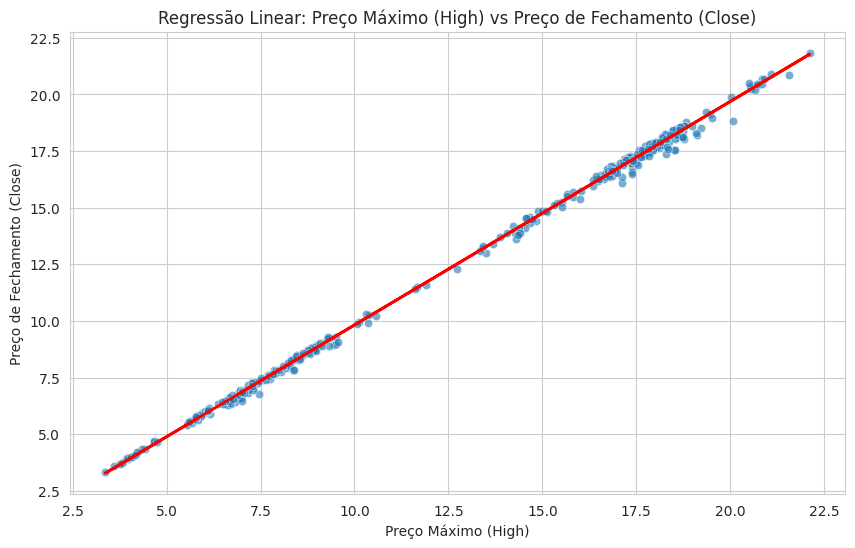

In [16]:
# Selecionar o atributo 'High' como nossa variável independente para este teste
X_high = df[['High']]

# Dividir os dados em conjuntos de treino e teste (usando o mesmo random_state)
X_train_high, X_test_high, y_train, y_test = train_test_split(X_high, y, test_size=0.2, random_state=42)

# Inicializar o modelo de Regressão Linear
model_high = LinearRegression()

# Treinar o modelo com os dados de treino
model_high.fit(X_train_high, y_train)

# Fazer previsões nos dados de teste
y_pred_high = model_high.predict(X_test_high)

# --- Visualização do Modelo 'High' vs 'Close' ---

plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_test_high['High'], y=y_test, alpha=0.6) # Dados reais (teste)
plt.plot(X_test_high['High'], y_pred_high, color='red', linewidth=2) # Linha de regressão
plt.title('Regressão Linear: Preço Máximo (High) vs Preço de Fechamento (Close)')
plt.xlabel('Preço Máximo (High)')
plt.ylabel('Preço de Fechamento (Close)')
plt.grid(True)
plt.savefig('regressao_high_close.png')
print("\nGráfico de regressão para 'High' vs 'Close' salvo como 'regressao_high_close.png'")

# --- Métricas do Modelo 'High' vs 'Close' ---
print("\nMétricas do Modelo de Regressão Linear ('High' vs 'Close'):")
print(f"Coeficiente (Slope): {model_high.coef_[0]:.4f}")
print(f"Intercepto (Intercept): {model_high.intercept_:.4f}")
print(f"R-quadrado (R²): {model_high.score(X_test_high, y_test):.4f}")

*A análise visual do gráfico de dispersão, juntamente com as métricas do modelo, revela uma conexão extraordinariamente forte e positiva, indicando que o preço High é um preditor muito eficaz para o preço Close. Os pontos de dados no gráfico de dispersão se aglomeram de forma muito densa ao redor da linha de regressão, demonstrando uma correlação linear quase perfeita.*

*O Coeficiente associado ao preço High neste modelo indica que, para cada unidade de aumento no preço máximo alcançado pela ação no dia, o preço de fechamento tende a aumentar em aproximadamente 0.9871 unidades. Este valor, extremamente próximo de 1, reforça a percepção de uma relação direta e quase de um para um. Isso faz sentido intuitivamente, pois o preço de fechamento, por definição, não pode exceder o preço máximo do dia.*

*O R-quadrado (R2) de 0.9987 é uma métrica que valida a capacidade do modelo de explicar a variabilidade no preço de Fechamento. Um valor tão alto significa que incríveis 99.87% da variação no preço de Fechamento pode ser explicada pelas mudanças no preço Máximo do dia. Este é um indicador de um ajuste de modelo quase perfeito e da altíssima capacidade preditiva do High em relação ao Close neste dataset.*

### Treinando o terceiro modelo: 'Low' vs 'Close'


Gráfico de regressão para 'Low' vs 'Close' salvo como 'regressao_low_close.png'

Métricas do Modelo de Regressão Linear ('Low' vs 'Close'):
Coeficiente (Slope): 1.0119
Intercepto (Intercept): 0.0548
R-quadrado (R²): 0.9990


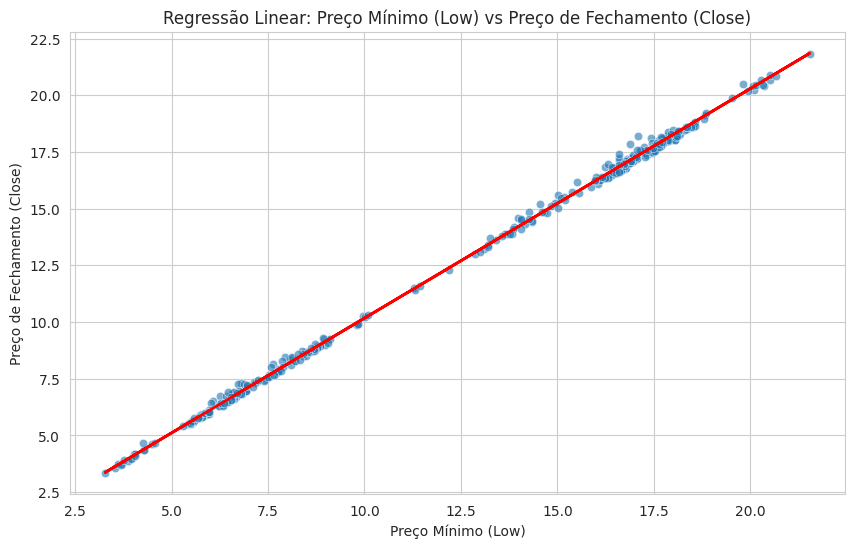

In [15]:
# Selecionar o atributo 'Low' como nossa variável independente para este teste
X_low = df[['Low']]

# Dividir os dados em conjuntos de treino e teste (usando o mesmo random_state)
X_train_low, X_test_low, y_train, y_test = train_test_split(X_low, y, test_size=0.2, random_state=42)

# Inicializar o modelo de Regressão Linear
model_low = LinearRegression()

# Treinar o modelo com os dados de treino
model_low.fit(X_train_low, y_train)

# Fazer previsões nos dados de teste
y_pred_low = model_low.predict(X_test_low)


# --- Visualização do Modelo 'Low' vs 'Close' ---

plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_test_low['Low'], y=y_test, alpha=0.6) # Dados reais (teste)
plt.plot(X_test_low['Low'], y_pred_low, color='red', linewidth=2) # Linha de regressão
plt.title('Regressão Linear: Preço Mínimo (Low) vs Preço de Fechamento (Close)')
plt.xlabel('Preço Mínimo (Low)')
plt.ylabel('Preço de Fechamento (Close)')
plt.grid(True)
plt.savefig('regressao_low_close.png')
print("\nGráfico de regressão para 'Low' vs 'Close' salvo como 'regressao_low_close.png'")

# --- Métricas do Modelo 'Low' vs 'Close' ---
print("\nMétricas do Modelo de Regressão Linear ('Low' vs 'Close'):")
print(f"Coeficiente (Slope): {model_low.coef_[0]:.4f}")
print(f"Intercepto (Intercept): {model_low.intercept_:.4f}")
print(f"R-quadrado (R²): {model_low.score(X_test_low, y_test):.4f}")

*A análise visual e numérica revelou uma conexão extremamente forte e direta entre essas duas variáveis. O gráfico de dispersão mostra que os pontos de dados se alinham de forma quase perfeita ao redor da linha de regressão, indicando uma dependência linear quase exata do Close em relação ao Low.*

*O Coeficiente (1.0119) do modelo demonstra que, para cada unidade de aumento no preço Low, o preço de Close tende a aumentar em aproximadamente 1.0119 unidades. Esse valor ligeiramente superior a 1 sugere que o preço de fechamento não apenas acompanha o preço mínimo, mas tende a ser um pouco mais alto em relação a ele, o que é esperado, já que o Close é tipicamente maior ou igual ao Low do dia.*

*O R-quadrado (textR2) de 0.9990 é um resultado notável, superando até mesmo os modelos anteriores (Open e High). Este valor significa que 99.90% da variância no preço de Fechamento pode ser explicada pela variação no preço Mínimo. Isso solidifica a conclusão de que o preço Low é um preditor excepcionalmente forte e confiável para o preço Close neste conjunto de dados, refletindo a estreita relação esperada entre o ponto mais baixo do dia e o valor de fechamento.*

### Treinando o quarto modelo: 'Volume' vs 'Close'


Gráfico de regressão para 'Volume' vs 'Close' salvo como 'regressao_volume_close.png'

Métricas do Modelo de Regressão Linear ('Volume' vs 'Close'):
Coeficiente (Slope): 0.00000034
Intercepto (Intercept): 11.9185
R-quadrado (R²): 0.0023


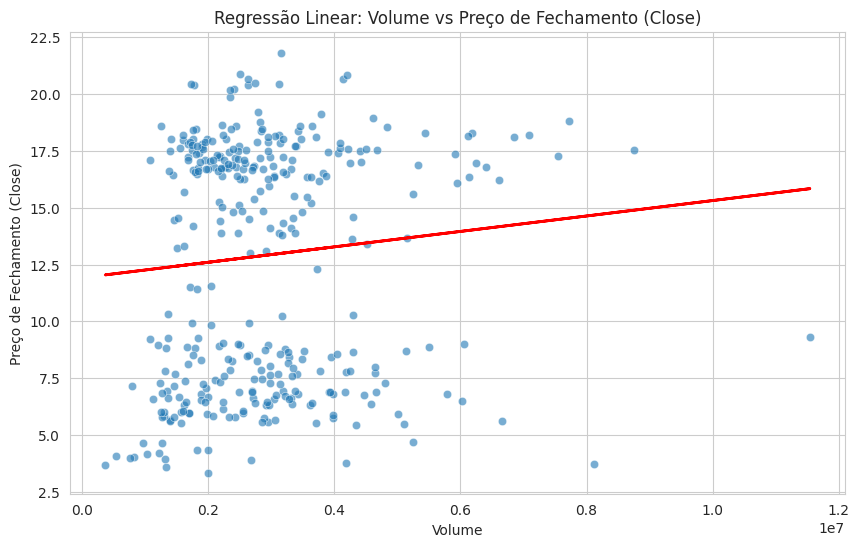

In [17]:
# Selecionar o atributo 'Volume' como nossa variável independente para este teste
X_volume = df[['Volume']]

# Dividir os dados em conjuntos de treino e teste (usando o mesmo random_state)
X_train_volume, X_test_volume, y_train, y_test = train_test_split(X_volume, y, test_size=0.2, random_state=42)

# Inicializar o modelo de Regressão Linear
model_volume = LinearRegression()

# Treinar o modelo com os dados de treino
model_volume.fit(X_train_volume, y_train)

# Fazer previsões nos dados de teste
y_pred_volume = model_volume.predict(X_test_volume)

# --- Visualização do Modelo 'Volume' vs 'Close' ---

plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_test_volume['Volume'], y=y_test, alpha=0.6) # Dados reais (teste)
plt.plot(X_test_volume['Volume'], y_pred_volume, color='red', linewidth=2) # Linha de regressão
plt.title('Regressão Linear: Volume vs Preço de Fechamento (Close)')
plt.xlabel('Volume')
plt.ylabel('Preço de Fechamento (Close)')
plt.grid(True)
plt.savefig('regressao_volume_close.png')
print("\nGráfico de regressão para 'Volume' vs 'Close' salvo como 'regressao_volume_close.png'")

# --- Métricas do Modelo 'Volume' vs 'Close' ---
print("\nMétricas do Modelo de Regressão Linear ('Volume' vs 'Close'):")
print(f"Coeficiente (Slope): {model_volume.coef_[0]:.8f}")
print(f"Intercepto (Intercept): {model_volume.intercept_:.4f}")
print(f"R-quadrado (R²): {model_volume.score(X_test_volume, y_test):.4f}")

*Ao contrário dos atributos de preço (Open, High, Low), a análise visual e as métricas para Volume revelam uma ausência quase completa de uma relação linear clara e direta com o Close. O gráfico de dispersão mostra os pontos de dados amplamente espalhados, sem uma tendência linear discernível em torno da linha de regressão.*

*O Coeficiente (0.00000034) para Volume é um valor extremamente próximo de zero. Isso indica que um aumento significativo no volume de negociações tem um efeito desprezível sobre o preço de fechamento. Em outras palavras, o volume, por si só, não é um fator que, de forma linear, puxa o preço de fechamento para cima ou para baixo de maneira previsível.*

*O R-quadrado (textR2) de 0.0023 é extremamente baixo, muito próximo de 0. Isso significa que apenas 0.23% da variação no preço de Fechamento pode ser explicada pela variação no Volume. Este valor sugere que o modelo de regressão linear, utilizando apenas o Volume, é um preditor muito pobre para o preço de Fechamento. Há muito pouca ou nenhuma relação linear entre o volume de negociação e o preço de fechamento para este conjunto de dados.*

*Em conclusão, a análise de Volume versus Close demonstra que, ao contrário dos atributos de preço, o volume não possui uma relação linear significativa com o preço de fechamento por si só. Isso significa que o Volume, isoladamente, não é um bom preditor linear do Close para esta ação.*